In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("/kaggle/input/datasets/abirhossainnishat/fake-newsss/Fake.csv")

df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [3]:
df = pd.read_csv("/kaggle/input/datasets/abirhossainnishat/true-news/True.csv")
df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [4]:
df["label"] = 0
df["label"] = 1 

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
 4   label    21417 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 836.7+ KB


In [6]:
df.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [7]:
df.shape

(21417, 5)

In [8]:
# Count missing values
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

In [9]:
# Number of duplicate rows
df.duplicated().sum()

# Drop duplicates if needed
df = df.drop_duplicates()

In [10]:
df.select_dtypes(include='object').columns

Index(['title', 'text', 'subject', 'date'], dtype='object')

In [11]:
df.describe(include="all")

,title,text,subject,date,label
count,21211,21211,21211,21211,21211.0
unique,20826,21192,2,716,NaN
top,Factbox: Trump fills top jobs for his administ...,TOKYO (Reuters) - U.S. President Donald Trump ...,politicsNews,"December 6, 2017",NaN
freq,14,2,11220,166,NaN
mean,NaN,NaN,NaN,NaN,1.0
std,NaN,NaN,NaN,NaN,0.0
min,NaN,NaN,NaN,NaN,1.0
25%,NaN,NaN,NaN,NaN,1.0
50%,NaN,NaN,NaN,NaN,1.0
75%,NaN,NaN,NaN,NaN,1.0


In [12]:
df.isnull().sum()

title      0
text       0
subject    0
date       0
label      0
dtype: int64

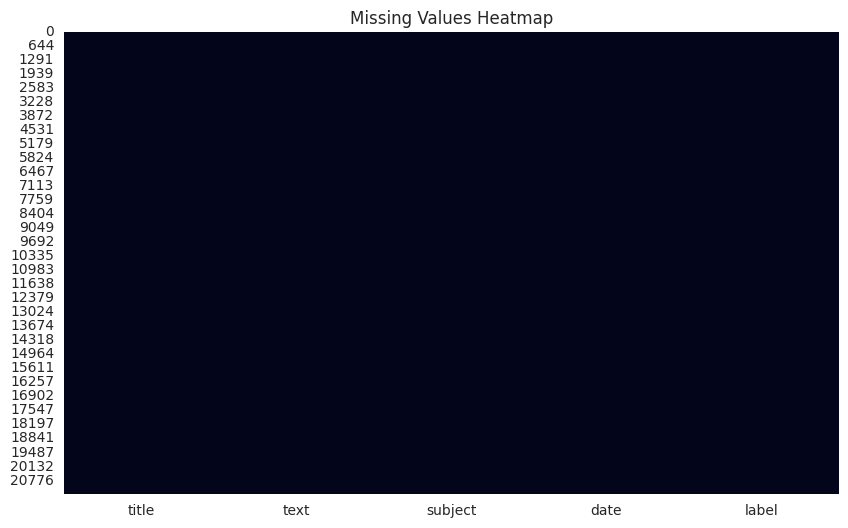

In [13]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

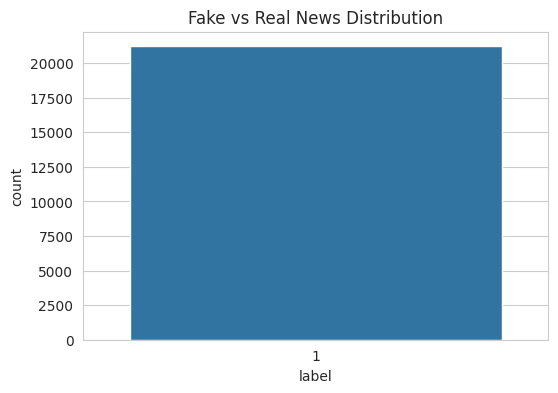

label
1    100.0
Name: proportion, dtype: float64

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=df)
plt.title("Fake vs Real News Distribution")
plt.show()

df["label"].value_counts(normalize=True) * 100

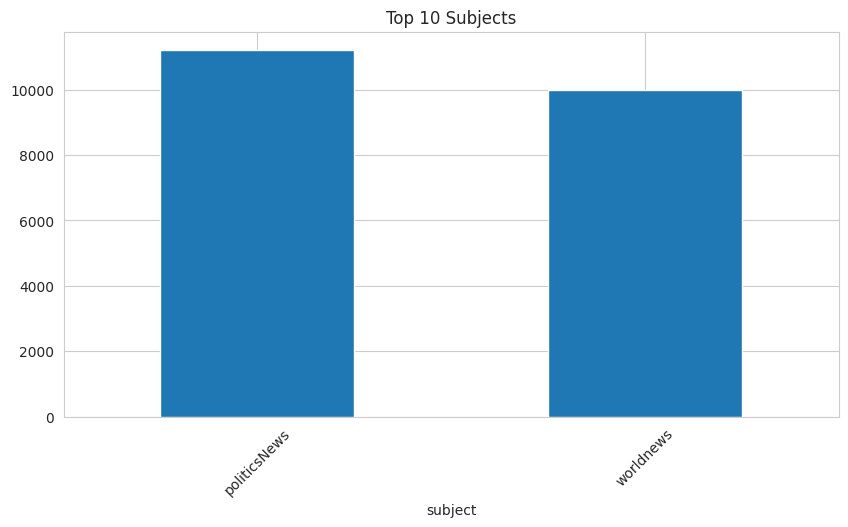

In [17]:
plt.figure(figsize=(10,5))
df['subject'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Subjects")
plt.xticks(rotation=45)
plt.show()

In [18]:
# Create text length column
df['text_length'] = df['text'].apply(lambda x: len(str(x)))

df['text_length'].describe()

count    21211.000000
mean      2378.042337
std       1684.467512
min          1.000000
25%        903.500000
50%       2216.000000
75%       3226.500000
max      29781.000000
Name: text_length, dtype: float64

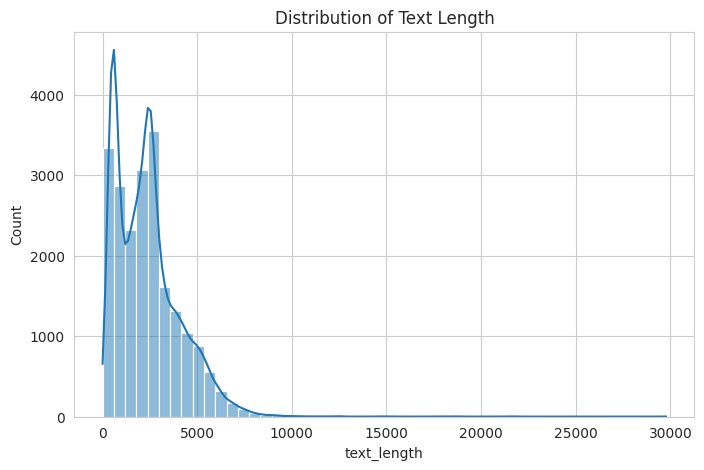

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['text_length'], bins=50, kde=True)
plt.title("Distribution of Text Length")
plt.show()

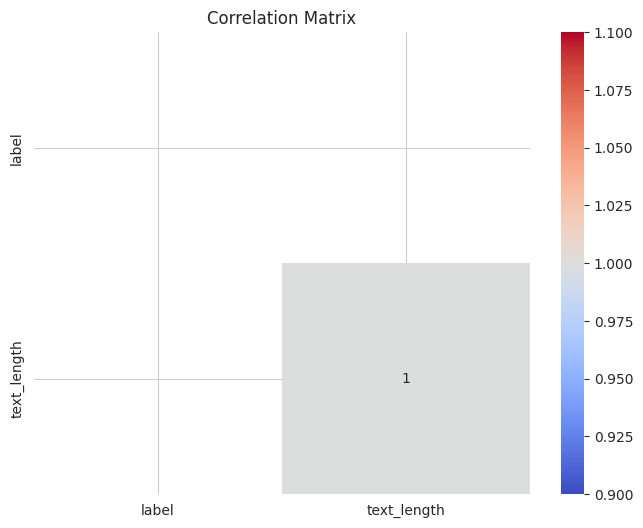

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

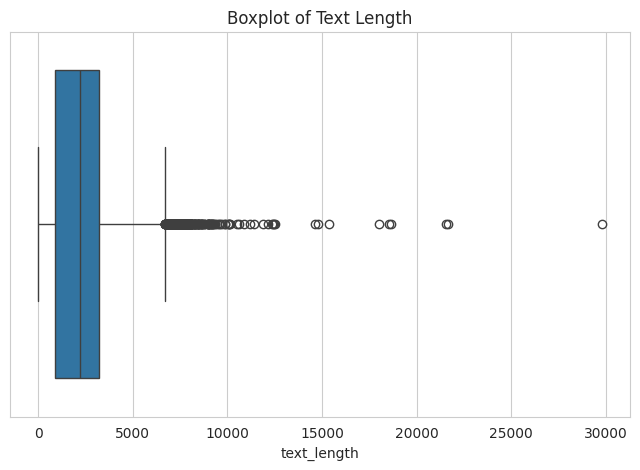

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['text_length'])
plt.title("Boxplot of Text Length")
plt.show()

In [22]:
df.to_csv("cleaned_fake_news.csv", index=False)